# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *

# DGP

In [6]:
# bernoulli specification
dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(0.1, 0.01), UnivariateGaussian(0.2, std=0.01)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

# continuous specification
# dgp_params = {
#     'n_experiments': 100, 
#     'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
#     'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
#     'dgp_seed': 0
# }

dgp = RCTs(**dgp_params)

In [7]:
samples = dgp.sample(sample_size=5000, seed=0)

# Estimation

In [8]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects(samples)

# Selection

In [9]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [10]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,0.202174
True Policy Value,0.200820
Winner's Curse,0.001354


In [11]:
del dgp, samples, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 866 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.2s finished


In [13]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.1104 (0.0004)
  - Average Estimated Value: 1.1459 (0.0009)
  - Average Winner's Curse (%): 35.52% (0.90%)


# Estimating Winner's Curse

In [22]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [15]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


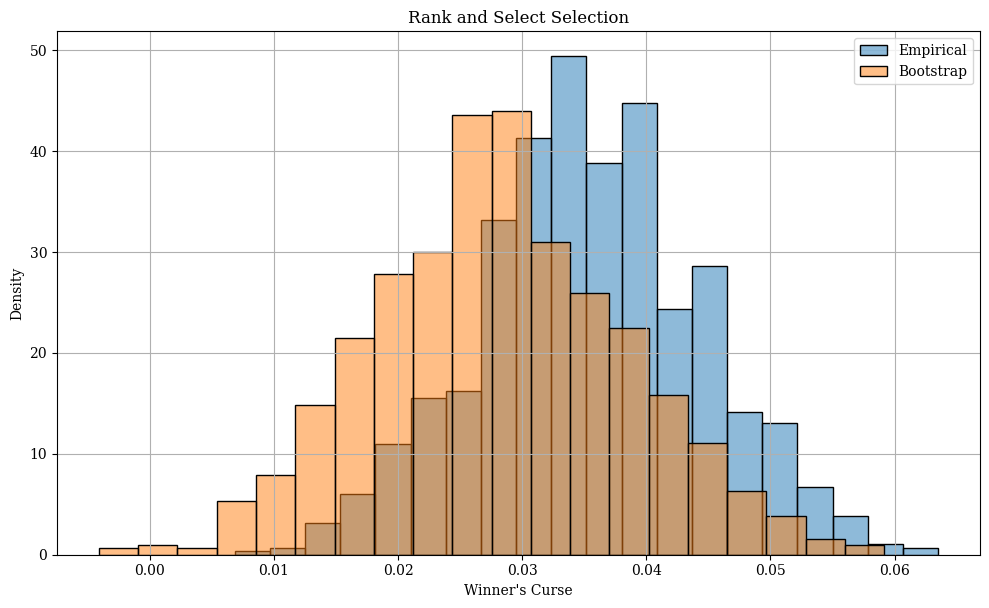

In [16]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [17]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


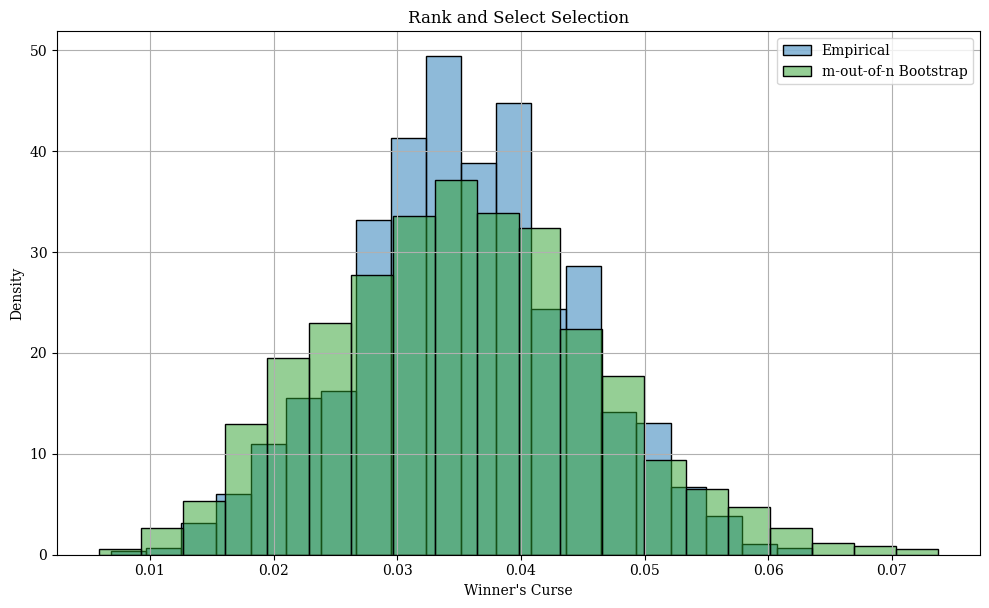

In [18]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [19]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


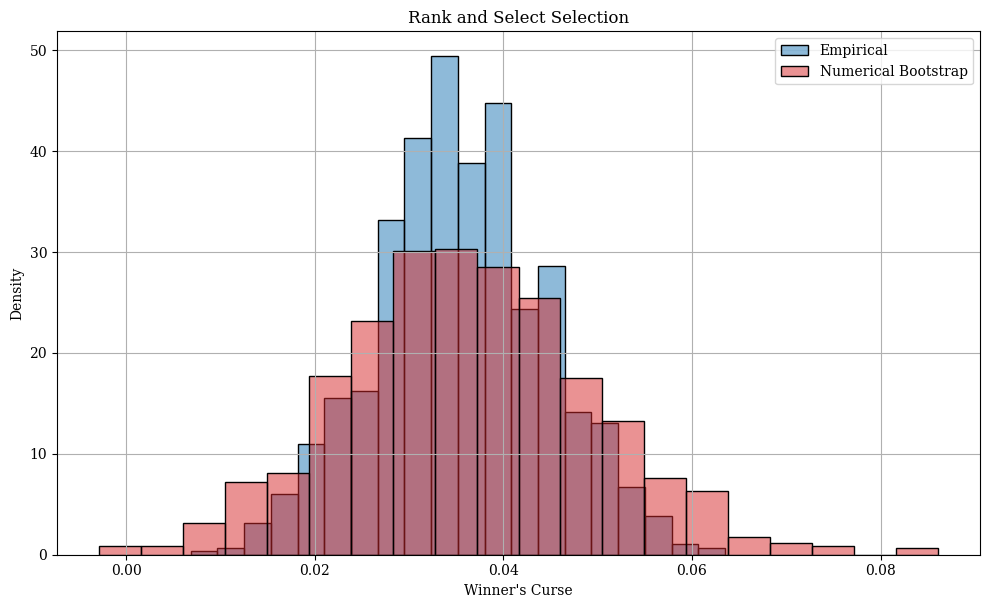

In [20]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [21]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate,
        'params': {'prior': 'normal', 'prior_mean': 0, 'prior_std': 1},
        'display_name': 'Bayes (Normal)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }
}

In [7]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   12.8s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   15.7s finished



Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0750 (0.0043)
  - No Correction: 1.1223 (0.0086)
  - Standard Bootstrap: 1.0872 (0.0098)
  - m-out-of-n Bootstrap: 1.0798 (0.0098)
  - Numerical Bootstrap: 1.0779 (0.0101)
  - Bayes (Normal): 1.1113 (0.0085)
  - (Andrews et al. 2024): 1.0042 (0.0379)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 47.32% (9.00%)
  - Standard Bootstrap: 12.21% (9.83%)
  - m-out-of-n Bootstrap: 4.75% (9.89%)
  - Numerical Bootstrap: 2.88% (10.09%)
  - Bayes (Normal): 36.35% (8.93%)
  - (Andrews et al. 2024): -70.87% (37.15%)
Median Winner's Curse: 
  - No Correction: 49.09% (9.00%)
  - Standard Bootstrap: 13.53% (9.83%)
  - m-out-of-n Bootstrap: 5.04% (9.89%)
  - Numerical Bootstrap: 4.71% (10.09%)
  - Bayes (Normal): 38.04% (8.93%)
  - (Andrews et al. 2024): 2.50% (37.15%)

Sample Splitting: 
  - True Value: 1.0686 (0.0046)
  - Estimated Value: 1.0711 (0.0148)
  - Winner's Curse (%): 2.52% (13.91%)


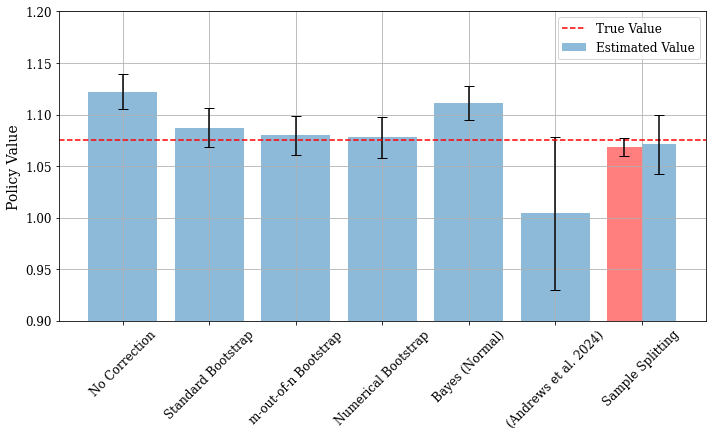

In [22]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


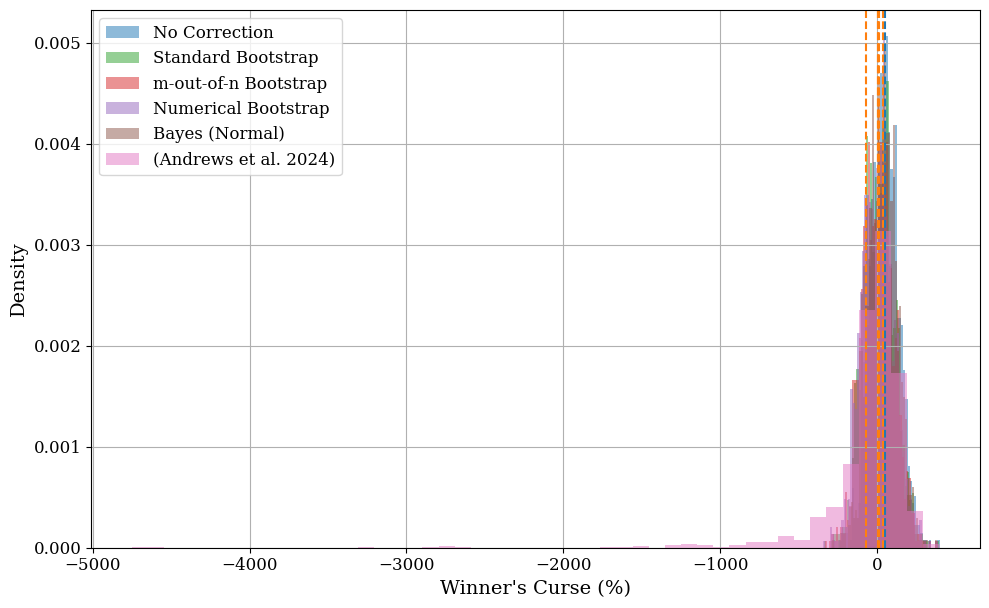

In [58]:
# plot the histogram of winner's curse
fig, ax  = plt.subplots(1, 1, figsize=(10, 6.18))

delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# plot the histogram of no correction
sns.histplot(
    wc_measures_dict['rank_and_select_nc_wc_arr'] / delta_tau * 100, 
    bins=50, color='C0', alpha=0.5, stat='density', label='No Correction', 
    edgecolor=None, ax=ax
)
ax.axvline(
    wc_measures_dict['rank_and_select_nc_wc_avg'] / delta_tau * 100, color='C0', linestyle='--'
)

for idx, estimator_key in enumerate(estimators_dict.keys()):
    if estimator_key == 'sample_splitting':
        continue

    estimator_name = estimators_dict[estimator_key]['display_name']

    sns.histplot(
        wc_measures_dict[f'rank_and_select_{estimator_key}_wc_arr'] / delta_tau * 100, 
        bins=50, color=f'C{idx+1}', alpha=0.5, stat='density', label=estimator_name, 
        edgecolor=None, ax=ax
    )
    ax.axvline(
        wc_measures_dict[f'rank_and_select_{estimator_key}_wc_avg'] / delta_tau * 100, color='C1', linestyle='--'
    )

ax.set_xlabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.grid()
ax.legend(fontsize=legend_label_size)

plt.tight_layout()
plt.show()

# Comparative Statics

## Number of Experiments

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': np.nan, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [16]:
n_tests_list = [10, 25, 50, 75, 100]

num_tests_result_dict = {n_tests: None for n_tests in n_tests_list}

for n_tests in n_tests_list:
    print(f'\nNumber of Experiments = {n_tests}')
    dgp_params['n_experiments'] = n_tests

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    num_tests_result_dict[n_tests] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   36.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   45.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 25
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   32.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 75
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  5.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  7.1min finished


In [17]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

num_tests_wc_avg_df = pd.DataFrame({
    num_tests: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for num_tests, wc_dict in num_tests_result_dict.items()
}).T / delta_tau * 100

num_tests_wc_se_df = pd.DataFrame({
    num_tests: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for num_tests, wc_dict in num_tests_result_dict.items()
}).T / delta_tau * 100

In [18]:
num_tests_wc_avg_df

,nc_wc_avg,sample_splitting_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_spike_slab_wc_avg,eb_spike_slab_adj_wc_avg
10,38.376925,-4.364785,5.776341,-1.171628,-2.541942,26.783315,14.922609,-5.764873
25,42.995880,-0.228715,9.780435,2.814563,1.188661,31.829144,20.086581,-5.159426
50,35.977950,0.369704,6.045016,-0.485512,-1.679282,24.757840,11.364657,-10.643960
75,33.099816,-0.227773,4.852107,-1.519334,-2.434244,21.738932,10.721700,-3.933909
100,35.541411,-0.300165,5.822965,-0.740956,-1.880803,24.311681,13.146945,-7.854716


In [19]:
num_tests_wc_se_df

,nc_wc_se,sample_splitting_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_spike_slab_wc_se,eb_spike_slab_adj_wc_se
10,2.837264,4.402822,3.118672,3.137370,3.207804,2.815677,2.777208,2.859078
25,1.808375,2.795986,1.984806,2.001275,2.044578,1.793758,1.753653,1.819289
50,1.328232,1.971177,1.452152,1.462393,1.480362,1.317135,1.294920,1.337471
75,1.051150,1.621882,1.155731,1.172159,1.190480,1.041965,1.019443,13.519997
100,0.882906,1.412605,0.956694,0.966662,0.976345,0.874677,0.866969,2.291048


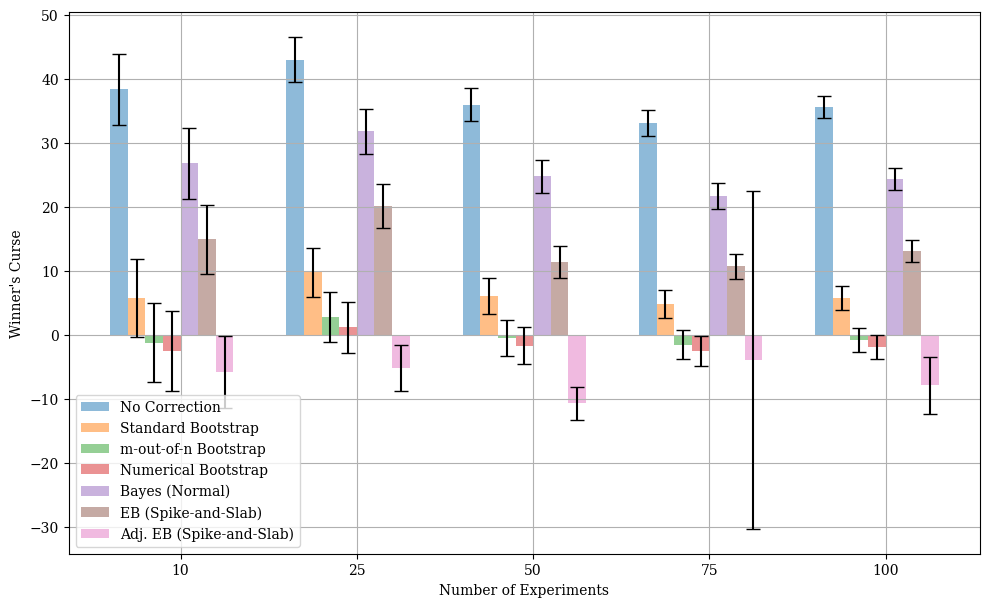

In [20]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'rank_and_select'

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(num_tests_wc_avg_df.index))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + [item for item in estimators_dict.keys() if item != 'sample_splitting']):

    bar_values = num_tests_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * num_tests_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Number of Experiments')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(num_tests_wc_avg_df.index)), 
    labels=num_tests_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

In [45]:
with open('results/ab_test_num_experiments.pkl', 'wb') as f:
    pickle.dump(num_tests_result_dict, f)

## Delta Tau

In [103]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

### $\tau_1 = 1.0$

In [104]:
base_tau = 1.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau1_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau1_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   10.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.05
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.1
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.5
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.3s finished


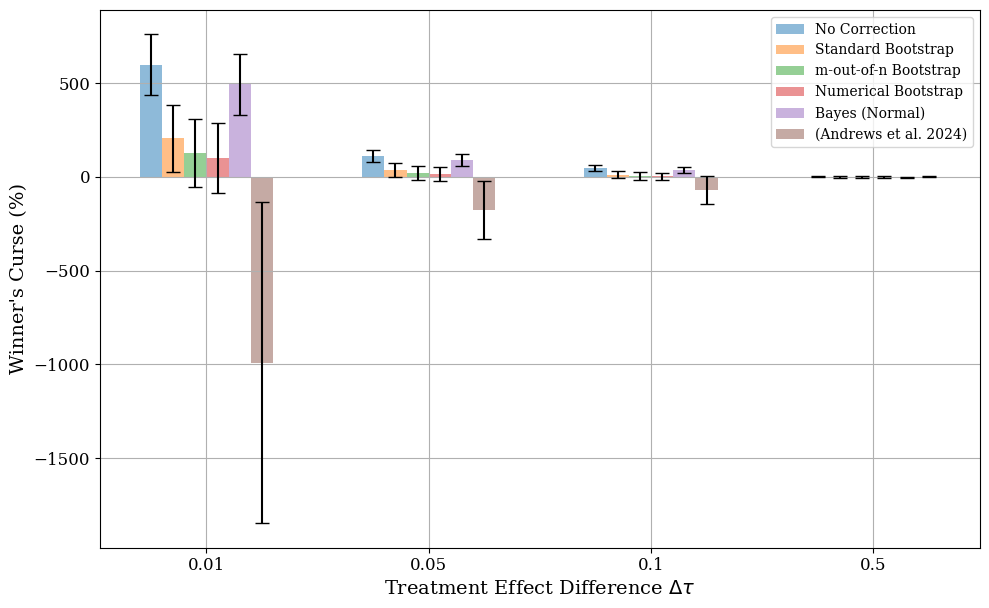

$\Delta\tau$=0.01  $\Delta\tau$=0.05  \
No Correction         Mean               596.69             112.34   
                      Median             606.28             117.58   
                      S.E.                82.75              16.96   
Standard Bootstrap    Mean               204.57              35.71   
                      Median             180.76              32.54   
                      S.E.                92.14              18.75   
m-out-of-n Bootstrap  Mean               128.81              20.58   
                      Median              95.48              15.26   
                      S.E.                92.37              18.80   
Numerical Bootstrap   Mean               102.00              15.59   
                      Median              82.03              11.58   
                      S.E.                94.83              19.29   
Bayes (Normal)        Mean               492.48              91.06   
                      Median             498.85              96.25   
                      S.E.                81.91              16.80   
(Andrews et al. 2024) Mean              -991.46            -179.33   
                      Median              38.65              17.05   
                      S.E.               436.21              78.81   

                              $\Delta\tau$=0.1  $\Delta\tau$=0.5  
No Correction         Mean               47.32              0.45  
                      Median             49.09              0.28  
                      S.E.                9.00              1.97  
Standard Bootstrap    Mean               12.21              0.15  
                      Median             13.53              0.18  
                      S.E.                9.83              2.01  
m-out-of-n Bootstrap  Mean                4.75             -0.15  
                      Median              5.04             -0.36  
                      S.E.                9.89              2.03  
Numerical Bootstrap   Mean                2.88              0.02  
                      Median              4.71             -0.44  
                      S.E.               10.09              2.03  
Bayes (Normal)        Mean               36.35             -2.48  
                      Median             38.04             -2.87  
                      S.E.                8.93              1.95  
(Andrews et al. 2024) Mean              -70.87              0.39  
                      Median              2.50              0.28  
                      S.E.               37.15              1.98

In [132]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau1_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# with open('results/ab_test_delta_tau1.pkl', 'wb') as f:
#     pickle.dump(delta_tau1_result_dict, f)

### $\tau_1 = 2.0$

In [123]:
base_tau = 2.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau2_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [PointMass(base_tau), PointMass(base_tau + delta_tau)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau2_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Delta tau= 0.01
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   10.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.05
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.1
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Delta tau= 0.5
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 937 out of 1000 | elapsed:    8.0s remaining:    0.4s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.4s finished


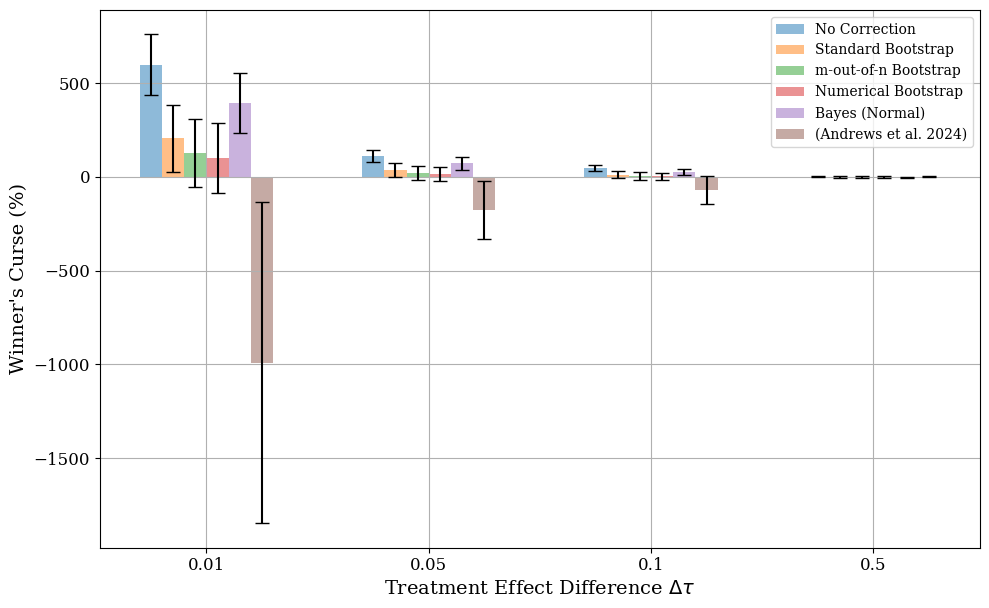

$\Delta\tau$=0.01  $\Delta\tau$=0.05  \
No Correction         Mean               596.69             112.34   
                      Median             606.28             117.58   
                      S.E.                82.75              16.96   
Standard Bootstrap    Mean               204.57              35.71   
                      Median             180.76              32.54   
                      S.E.                92.14              18.75   
m-out-of-n Bootstrap  Mean               128.81              20.58   
                      Median              95.48              15.26   
                      S.E.                92.37              18.80   
Numerical Bootstrap   Mean               102.00              15.59   
                      Median              82.03              11.58   
                      S.E.                94.83              19.29   
Bayes (Normal)        Mean               394.65              71.49   
                      Median             397.56              74.43   
                      S.E.                81.89              16.79   
(Andrews et al. 2024) Mean              -991.46            -179.33   
                      Median              38.65              17.05   
                      S.E.               436.21              78.81   

                              $\Delta\tau$=0.1  $\Delta\tau$=0.5  
No Correction         Mean               47.32              0.45  
                      Median             49.09              0.28  
                      S.E.                9.00              1.97  
Standard Bootstrap    Mean               12.21              0.15  
                      Median             13.53              0.18  
                      S.E.                9.83              2.01  
m-out-of-n Bootstrap  Mean                4.75             -0.15  
                      Median              5.04             -0.36  
                      S.E.                9.89              2.03  
Numerical Bootstrap   Mean                2.88              0.02  
                      Median              4.71             -0.44  
                      S.E.               10.09              2.03  
Bayes (Normal)        Mean               26.57             -4.44  
                      Median             29.17             -4.71  
                      S.E.                8.93              1.95  
(Andrews et al. 2024) Mean              -70.87              0.39  
                      Median              2.50              0.28  
                      S.E.               37.15              1.98

In [130]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = delta_tau2_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for delta_tau in delta_tau_list:
    data[delta_tau] = {}

    data[delta_tau]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[delta_tau][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[delta_tau][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for delta_tau in delta_tau_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[delta_tau][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\Delta\tau={}$'.format(d) for d in delta_tau_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(delta_tau_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[dt][estimator]['Mean'] for dt in delta_tau_list]
    bar_errors = [1.96 * data[dt][estimator]['S.E.'] for dt in delta_tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Treatment Effect Difference $\Delta\tau$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(delta_tau_list)), labels=delta_tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# with open('results/ab_test_delta_tau2.pkl', 'wb') as f:
#     pickle.dump(delta_tau2_result_dict, f)

## Sample Size

In [125]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [126]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True, truncate_lb=-3.0, truncate_ub=3.0
    )


Sample Size = 50
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 500
Running 1000 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.7s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 2500
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   10.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 5000
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   12.8s finished


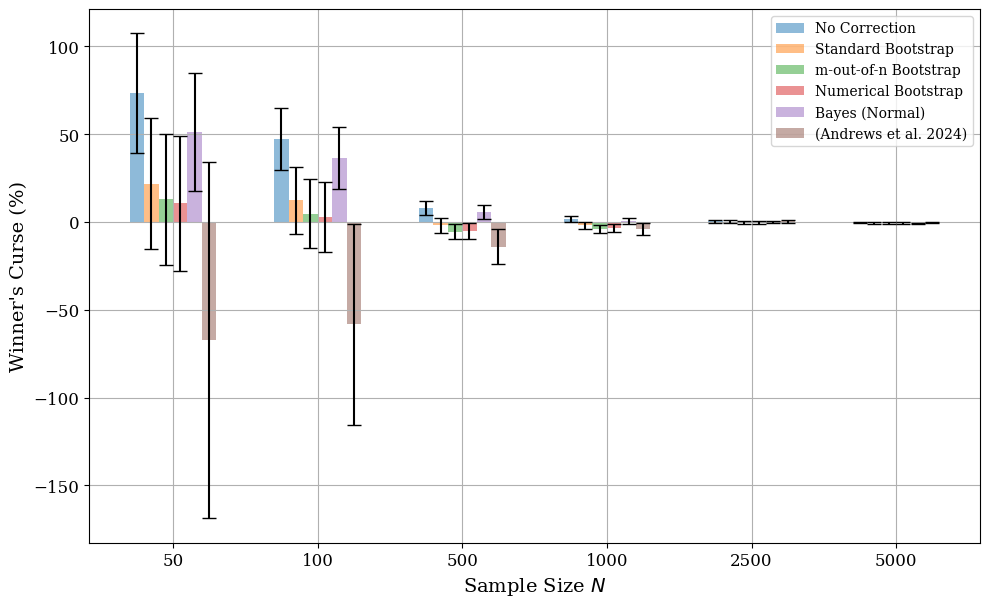

$N$=50  $N$=100  $N$=500  $N$=1000  $N$=2500  \
No Correction         Mean     73.28    47.32     7.65      1.68      0.38   
                      Median   76.40    49.09     6.99      2.85      0.67   
                      S.E.     17.39     9.00     2.02      0.97      0.40   
Standard Bootstrap    Mean     21.71    12.21    -1.94     -1.99      0.00   
                      Median   22.74    13.53    -1.32      0.09      0.53   
                      S.E.     19.05     9.83     2.21      1.06      0.42   
m-out-of-n Bootstrap  Mean     12.80     4.75    -5.53     -4.17     -0.48   
                      Median   12.96     5.04    -5.43     -2.53      0.30   
                      S.E.     19.11     9.89     2.25      1.09      0.43   
Numerical Bootstrap   Mean     10.53     2.88    -5.32     -3.35     -0.19   
                      Median    8.29     4.71    -3.52     -1.47      0.32   
                      S.E.     19.52    10.09     2.29      1.11      0.42   
Bayes (Normal)        Mean     51.14    36.35     5.46      0.58     -0.06   
                      Median   52.79    38.04     4.58      1.74      0.24   
                      S.E.     17.11     8.93     2.01      0.97      0.40   
(Andrews et al. 2024) Mean    -67.40   -58.39   -14.18     -3.89      0.25   
                      Median   13.67     2.85     0.20      1.25      0.67   
                      S.E.     51.76    29.23     5.11      1.80      0.41   

                              $N$=5000  
No Correction         Mean       -0.53  
                      Median     -0.77  
                      S.E.        0.19  
Standard Bootstrap    Mean       -0.55  
                      Median     -0.87  
                      S.E.        0.19  
m-out-of-n Bootstrap  Mean       -0.55  
                      Median     -0.80  
                      S.E.        0.19  
Numerical Bootstrap   Mean       -0.57  
                      Median     -0.83  
                      S.E.        0.19  
Bayes (Normal)        Mean       -0.75  
                      Median     -0.99  
                      S.E.        0.19  
(Andrews et al. 2024) Mean       -0.53  
                      Median     -0.77  
                      S.E.        0.19

In [131]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [96]:
with open('results/ab_test_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

## Response STD

In [135]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [136]:
response_std_list = [0.5, 1, 2, 3, 4, 5]

response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nResponse Standard Deviation = {response_std}')
    
    dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    response_std_result_dict[response_std] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Response Standard Deviation = 0.5
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   10.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 1
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.4s
[Parallel(n_jobs=-1)]: Done 937 out of 1000 | elapsed:    8.4s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 2
Running 1000 experiments...


...

[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 4
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 937 out of 1000 | elapsed:    8.2s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Response Standard Deviation = 5
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 708 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 937 out of 1000 | elapsed:    8.2s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.5s finished


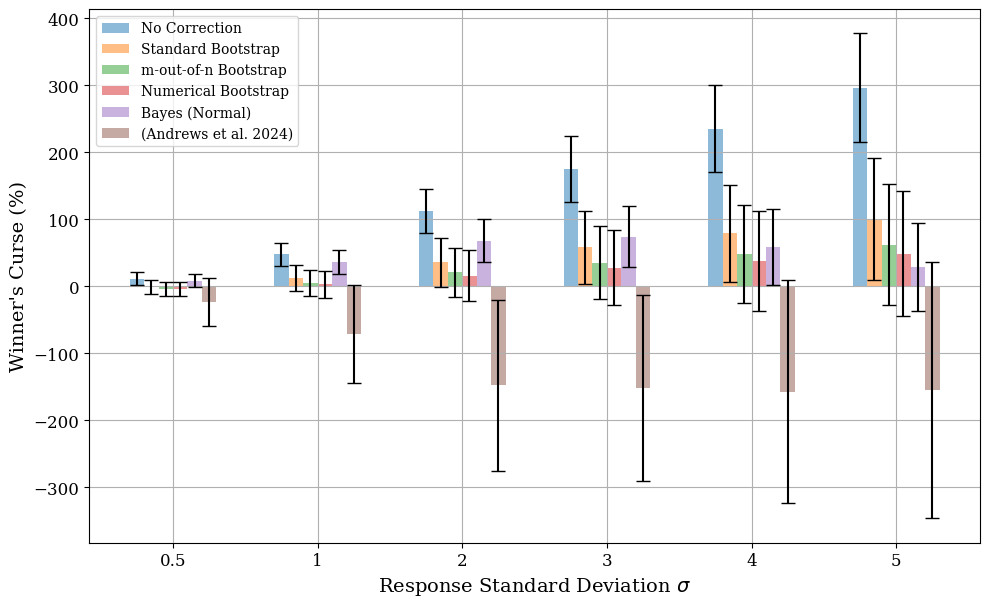

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  \
No Correction         Mean           11.19       47.32      112.34   
                      Median         10.97       49.09      117.58   
                      S.E.            4.84        9.00       16.96   
Standard Bootstrap    Mean           -0.97       12.21       35.71   
                      Median         -0.40       13.53       32.54   
                      S.E.            5.29        9.83       18.75   
m-out-of-n Bootstrap  Mean           -4.21        4.75       20.58   
                      Median         -5.17        5.04       15.26   
                      S.E.            5.35        9.89       18.80   
Numerical Bootstrap   Mean           -4.25        2.88       15.59   
                      Median         -5.69        4.71       11.58   
                      S.E.            5.43       10.09       19.29   
Bayes (Normal)        Mean            8.48       36.35       67.67   
                      Median          8.05       38.04       71.86   
                      S.E.            4.83        8.93       16.35   
(Andrews et al. 2024) Mean          -23.84      -70.87     -148.05   
                      Median         -2.30        2.50       20.23   
                      S.E.           18.39       37.15       65.18   

                              $\sigma=3$  $\sigma=4$  $\sigma=5$  
No Correction         Mean        174.72      235.08      295.83  
                      Median      179.40      241.31      301.63  
                      S.E.         25.10       33.36       41.54  
Standard Bootstrap    Mean         58.10       78.82      100.07  
                      Median       53.25       70.79       88.09  
                      S.E.         27.84       37.06       46.20  
m-out-of-n Bootstrap  Mean         35.36       48.44       62.19  
                      Median       25.87       37.58       50.25  
                      S.E.         27.93       37.16       46.31  
Numerical Bootstrap   Mean         27.55       37.88       48.76  
                      Median       21.65       31.69       42.08  
                      S.E.         28.65       38.13       47.54  
Bayes (Normal)        Mean         74.13       59.09       29.15  
                      Median       79.91       65.23       33.28  
                      S.E.         23.12       28.95       33.53  
(Andrews et al. 2024) Mean       -151.98     -157.27     -154.80  
                      Median       24.85       38.33       59.81  
                      S.E.         70.97       84.96       97.74

In [139]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [48]:
with open('results/ab_test_response_std.pkl', 'wb') as f:
    pickle.dump(response_std_result_dict, f)

## $\Delta\tau / \sigma$

In [140]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [ ]:
ratio_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

response_std_list = [1, 2, 3]

ratio_result_dict = {}

for ratio in ratio_list:
    for response_std in response_std_list:
        delta_tau = response_std * ratio
        print(f'\nRatio = {ratio}; Response Standard Deviation = {response_std}; Delta tau= {delta_tau}')

        dgp_params['base_effects'] = [PointMass(1), PointMass(1 + delta_tau)]
        dgp_params['noise_vars'] = [UnivariateGaussian(0, std=response_std), UnivariateGaussian(0, std=response_std)]

        result_records = rct.repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict,
            verbose=True, 
            n_jobs=-1
        )

        ratio_result_dict[(delta_tau, response_std, ratio)] = rct.calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )

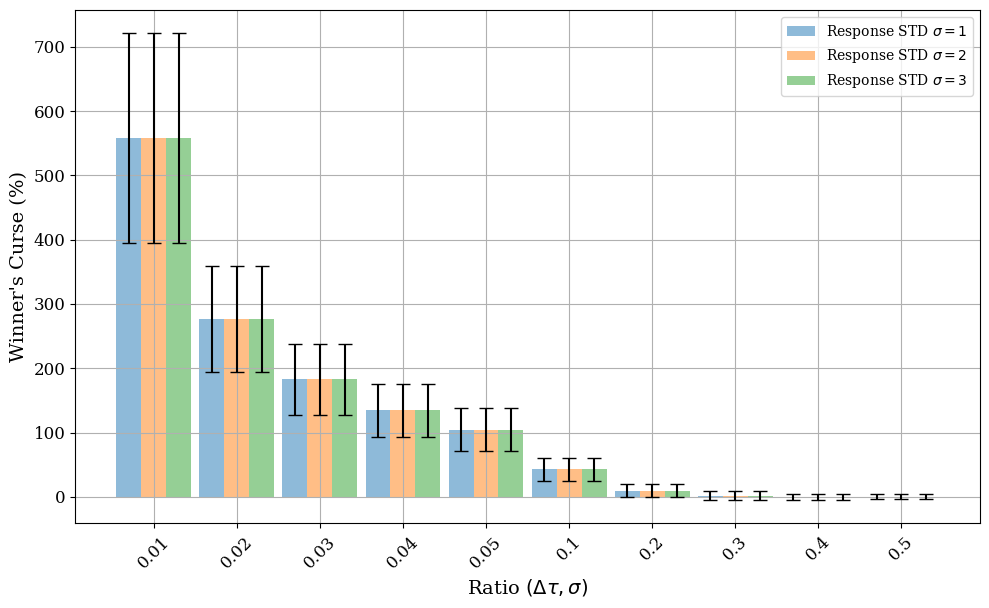

0.01  \
                             $(\Delta\tau, \sigma) = (0.01, 1)$   
No Correction         Mean                               557.93   
                      Median                             581.37   
                      S.E.                                83.15   
Standard Bootstrap    Mean                               166.07   
                      Median                             149.28   
                      S.E.                                92.93   
m-out-of-n Bootstrap  Mean                                92.06   
                      Median                              59.35   
                      S.E.                                92.85   
Numerical Bootstrap   Mean                                66.38   
                      Median                              62.25   
                      S.E.                                95.59   
Bayes (Normal)        Mean                               454.27   
                      Median                             474.08   
                      S.E.                                82.37   
(Andrews et al. 2024) Mean                             -1074.33   
                      Median                              73.82   
                      S.E.                               468.06   

                                                                 \
                             $(\Delta\tau, \sigma) = (0.02, 2)$   
No Correction         Mean                               557.93   
                      Median                             581.37   
                      S.E.                                83.15   
Standard Bootstrap    Mean                               166.07   
                      Median                             149.28   
                      S.E.                                92.93   
m-out-of-n Bootstrap  Mean                                92.06   
                      Median                              59.35   
                      S.E.                                92.85   
Numerical Bootstrap   Mean                                66.38   
                      Median                              62.25   
                      S.E.                                95.59   
Bayes (Normal)        Mean                               345.08   
                      Median                             356.87   
                      S.E.                                80.09   
(Andrews et al. 2024) Mean                              -727.09   
                      Median                              96.63   
                      S.E.                               312.54   

                                                                 \
                             $(\Delta\tau, \sigma) = (0.03, 3)$   
No Correction         Mean                               557.93   
                      Median                             581.37   
                      S.E.                                83.15   
Standard Bootstrap    Mean                               166.07   
                      Median                             149.28   
                      S.E.                                92.93   
m-out-of-n Bootstrap  Mean                                92.06   
                      Median                              59.35   
                      S.E.                                92.85   
Numerical Bootstrap   Mean                                66.38   
                      Median                              62.25   
                      S.E.                                95.59   
Bayes (Normal)        Mean                               236.84   
                      Median                             258.40   
                      S.E.                                76.56   
(Andrews et al. 2024) Mean                              -568.38   
                      Median                              99.22   
                      S.E.                               259.53   

                                    

In [160]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = ratio_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau, response_std, ratio = key

    data[(delta_tau, response_std)] = {}

    data[(delta_tau, response_std)]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[(delta_tau, response_std)][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (ratio, '$(\Delta\tau, \sigma) = ({}, {})$'.format(delta_tau, response_std))
    for delta_tau, response_std, ratio in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for delta_tau, response_std, _ in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[(delta_tau, response_std)][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(ratio_list))
bar_width = 0.3 * len(response_std_list)

for idx, response_std in enumerate(response_std_list):
    bar_values = [data[(dt, std)]['No Correction']['Mean'] for dt, std, _ in result_dict.keys() if std == response_std]
    bar_errors = [1.96 * data[(dt, std)]['No Correction']['S.E.'] for dt, std, _ in result_dict.keys() if std == response_std]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / len(response_std_list) + bar_width / 2 / len(response_std_list), 
        bar_values, yerr=bar_errors, 
        capsize=5, alpha=0.5, width=bar_width / len(response_std_list),
        label=r'Response STD $\sigma={}$'.format(response_std)
    )

ax.set_xlabel(r'Ratio $(\Delta\tau, \sigma)$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(ratio_list)), 
    labels=ratio_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

## Noise distribution

In [163]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(1), PointMass(1.1)],
    'noise_vars': None,
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [164]:
noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\sqrt{3}$, $-\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    'Student T (Dof = 100)': StudentT(100), 
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

noise_dstn_result_dict = {noise_dstn: None for noise_dstn in noise_dstn_dict.keys()}

for noise_key, noise_dstn in noise_dstn_dict.items():
    print(f'\nNoise Distribution = {noise_key}')
    
    dgp_params['noise_vars'] = [noise_dstn, noise_dstn]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    noise_dstn_result_dict[noise_key] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution = Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Student T (Dof = 100)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 437 out of 500 | elapsed:    3.8s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Noise Distribution = Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.2s finished


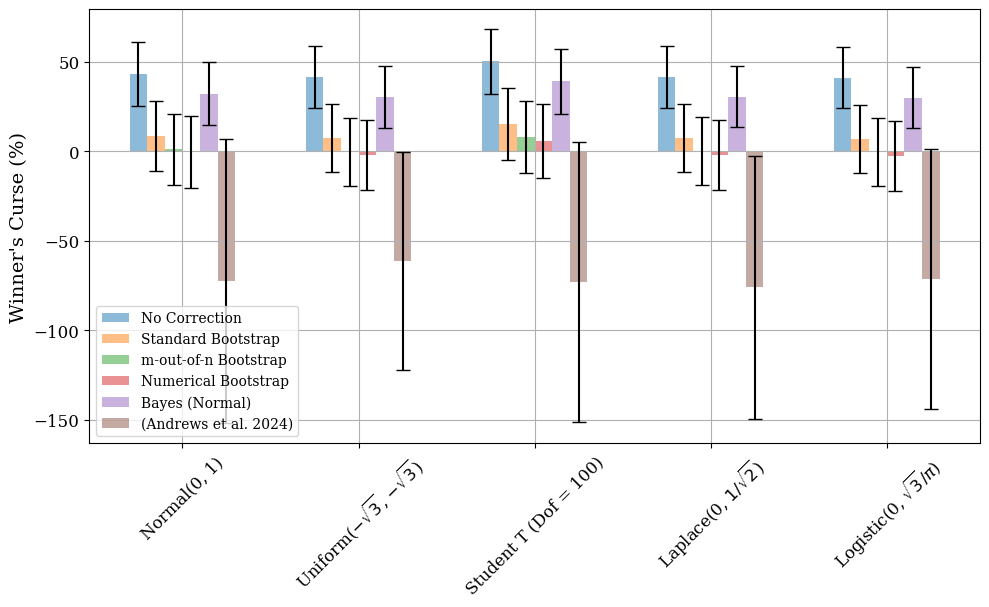

Normal(0, 1)  Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction         Mean           43.15                              41.52   
                      Median         44.99                              39.93   
                      S.E.            9.10                               8.83   
Standard Bootstrap    Mean            8.42                               7.23   
                      Median          9.37                               8.74   
                      S.E.            9.99                               9.71   
m-out-of-n Bootstrap  Mean            1.13                              -0.13   
                      Median          1.23                               1.53   
                      S.E.           10.03                               9.72   
Numerical Bootstrap   Mean           -0.59                              -1.97   
                      Median         -0.15                              -1.15   
                      S.E.           10.24                               9.94   
Bayes (Normal)        Mean           32.22                              30.51   
                      Median         35.28                              28.58   
                      S.E.            9.02                               8.77   
(Andrews et al. 2024) Mean          -72.66                             -61.35   
                      Median          1.10                              -3.90   
                      S.E.           40.48                              30.99   

                              Student T (Dof = 100)  Laplace(0, $1/\sqrt{2}$)  \
No Correction         Mean                    50.32                     41.66   
                      Median                  43.46                     37.57   
                      S.E.                     9.30                      8.77   
Standard Bootstrap    Mean                    15.05                      7.53   
                      Median                   8.53                      6.01   
                      S.E.                    10.28                      9.75   
m-out-of-n Bootstrap  Mean                     7.99                      0.23   
                      Median                   0.82                      1.53   
                      S.E.                    10.39                      9.76   
Numerical Bootstrap   Mean                     5.70                     -1.97   
                      Median                  -2.57                     -0.47   
                      S.E.                    10.57                     10.00   
Bayes (Normal)        Mean                    39.08                     30.47   
                      Median                  32.60                     26.50   
                      S.E.                     9.22                      8.69   
(Andrews et al. 2024) Mean                   -73.05                    -76.03   
                      Median                   2.55                      4.00   
                      S.E.                    39.98                     37.44   

                              Logistic(0, $\sqrt{3} / \pi$)  
No Correction         Mean                            41.09  
                      Median                          37.58  
                      S.E.                             8.72  
Standard Bootstrap    Mean                             6.86  
                      Median                           4.62  
                      S.E.                             9.69  
m-out-of-n Bootstrap  Mean                            -0.50  
                      Median                          -2.46  
                      S.E.                             9.70  
Numerical Bootstrap   Mean                            -2.49  
                      Median                          -4.10  
                      S.E.                             9.95  
Bayes (Normal)        Mean                            29.96  
                      Median                          26.93  
                    

In [168]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

# Bernoulli Response

In [6]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': None,
    'noise_vars': None,
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [7]:
bernoulli_te_list = [
    (0.1, 0.11), (0.2, 0.21), (0.3, 0.31), (0.1, 0.15), (0.2, 0.25), (0.3, 0.35)
]

bernoulli_te_result_dict = {bernoulli_te: None for bernoulli_te in bernoulli_te_list}

for te_tuple in bernoulli_te_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effects'] = [UnivariateGaussian(te_tuple[0], std=0.01), UnivariateGaussian(te_tuple[1], std=0.01)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_te_result_dict[te_tuple] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params, 
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


(tau_1, tau_2)= (0.1, 0.11)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    6.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.21)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 208 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 437 out of 500 | elapsed:    4.0s remaining:    0.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.3, 0.31)
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.2, 0.25)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (0.3, 0.35)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    4.3s finished


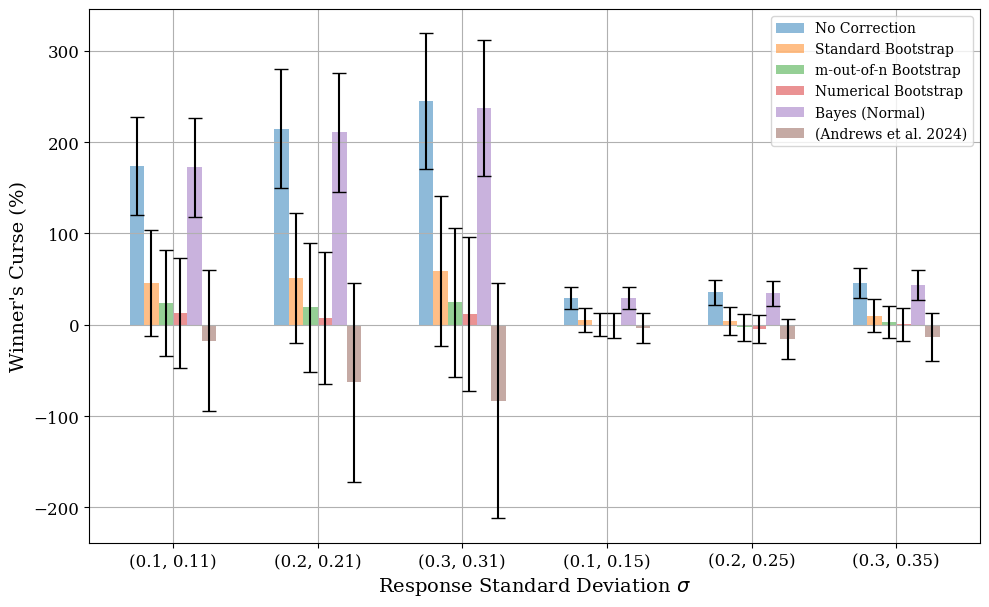

$\Delta\tau = 0.01$  \
                             $(\tau_1, \tau_2)$ = (0.1, 0.11)   
No Correction         Mean                             173.99   
                      Median                           159.98   
                      S.E.                              27.61   
Standard Bootstrap    Mean                              45.72   
                      Median                            28.69   
                      S.E.                              29.83   
m-out-of-n Bootstrap  Mean                              23.81   
                      Median                             2.03   
                      S.E.                              29.66   
Numerical Bootstrap   Mean                              12.84   
                      Median                           -15.47   
                      S.E.                              30.54   
Bayes (Normal)        Mean                             172.40   
                      Median                           158.52   
                      S.E.                              27.56   
(Andrews et al. 2024) Mean                             -17.30   
                      Median                            23.59   
                      S.E.                              39.60   

                                                               \
                             $(\tau_1, \tau_2)$ = (0.2, 0.21)   
No Correction         Mean                             214.95   
                      Median                           223.59   
                      S.E.                              33.30   
Standard Bootstrap    Mean                              51.15   
                      Median                            28.89   
                      S.E.                              36.40   
m-out-of-n Bootstrap  Mean                              19.23   
                      Median                            -7.77   
                      S.E.                              36.04   
Numerical Bootstrap   Mean                               7.51   
                      Median                           -16.21   
                      S.E.                              37.09   
Bayes (Normal)        Mean                             210.63   
                      Median                           219.23   
                      S.E.                              33.20   
(Andrews et al. 2024) Mean                             -62.92   
                      Median                            23.59   
                      S.E.                              55.47   

                                                               \
                             $(\tau_1, \tau_2)$ = (0.3, 0.31)   
No Correction         Mean                             245.04   
                      Median                           223.59   
                      S.E.                              37.88   
Standard Bootstrap    Mean                              59.40   
                      Median                            39.59   
                      S.E.                              41.94   
m-out-of-n Bootstrap  Mean                              24.49   
                      Median                             9.78   
                      S.E.                              41.55   
Numerical Bootstrap   Mean                              11.51   
                      Median                           -14.78   
                      S.E.                              43.08   
Bayes (Normal)        Mean                             237.42   
                      Median                           215.98   
                      S.E.                              37.76   
(Andrews et al. 2024) Mean                             -83.00   
                      Median                            -1.05   
                      S.E.                              65.88   

                                          $\Delta\tau = 0.05$  \
                             $(\tau_1, \tau_2)$ = (0.1, 0.15)   
No Correc

In [10]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_te_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(bernoulli_te_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in bernoulli_te_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in bernoulli_te_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(bernoulli_te_list)), labels=bernoulli_te_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# with open('results/ab_test_bernoulli_delta_tau.pkl', 'wb') as f:
#     pickle.dump(bernoulli_te_result_dict, f)

## Sample Size

In [13]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 1, 
    'base_effects': [PointMass(0.1), PointMass(0.11)],
    'response_type': 'bernoulli',
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 1000}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'cond_selective_inference': {
        'estimator': rct.conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': rct.empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'eb_spike_slab_adj': {
    #     'estimator': rct.empirical_bayes_selection_adjusted_estimate,
    #     'params': {
    #         'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
    #     },
    #     'display_name': 'Adj. EB (Spike-and-Slab)'
    # }
}

In [14]:
sample_size_list = [50, 100, 500, 1000, 2500, 5000]

bernoulli_sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    truncate_bound = 2 * max(dgp_params['base_effects'][0].mean, dgp_params['base_effects'][1].mean)

    bernoulli_sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params,
        truncate_outliers=True,  # remove outliers due to numerical instability
        truncate_lb=-truncate_bound, truncate_ub=truncate_bound
    )


Sample Size = 50
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.7s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   11.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    8.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 500
Running 1000 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    9.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 2500
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   11.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 5000
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 736 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   13.8s finished


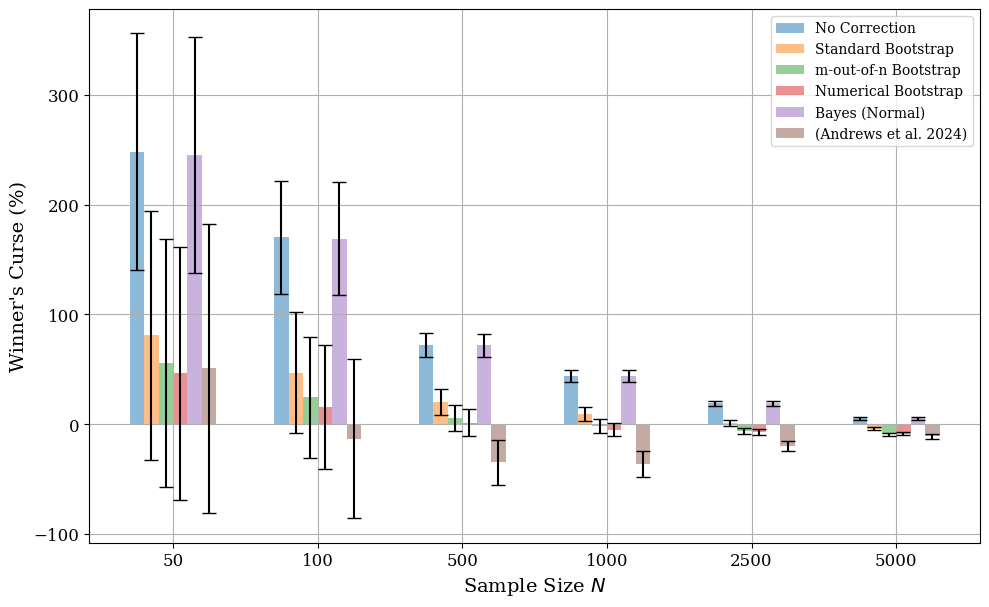

$N=50$  $N=100$  $N=500$  $N=1000$  $N=2500$  \
No Correction         Mean    248.50   170.30    72.06     43.75     19.04   
                      Median  200.00   200.00    60.00     40.00     18.00   
                      S.E.     54.97    26.29     5.52      2.79      1.20   
Standard Bootstrap    Mean     80.93    46.84    20.05      9.34      1.19   
                      Median   41.80    16.70     8.72      6.98      1.11   
                      S.E.     58.03    28.20     6.01      3.05      1.30   
m-out-of-n Bootstrap  Mean     55.57    24.66     6.00     -1.69     -6.06   
                      Median   19.29    -7.36    -5.95     -3.62     -5.88   
                      S.E.     57.69    28.10     6.04      3.07      1.33   
Numerical Bootstrap   Mean     46.34    15.90     1.50     -4.90     -7.24   
                      Median    5.05   -16.83   -10.76     -7.95     -5.51   
                      S.E.     58.96    28.92     6.21      3.17      1.37   
Bayes (Normal)        Mean    245.38   168.94    71.83     43.64     19.00   
                      Median  197.47   198.53    59.76     39.90     17.96   
                      S.E.     54.74    26.24     5.51      2.79      1.20   
(Andrews et al. 2024) Mean     50.77   -13.11   -34.64    -36.25    -19.63   
                      Median   27.37    -1.40    10.96     -0.16      1.88   
                      S.E.     67.04    37.13    10.54      6.02      2.44   

                              $N=5000$  
No Correction         Mean        5.27  
                      Median      2.00  
                      S.E.        0.64  
Standard Bootstrap    Mean       -3.99  
                      Median     -5.03  
                      S.E.        0.69  
m-out-of-n Bootstrap  Mean       -9.14  
                      Median    -10.37  
                      S.E.        0.71  
Numerical Bootstrap   Mean       -8.81  
                      Median     -9.61  
                      S.E.        0.73  
Bayes (Normal)        Mean        5.25  
                      Median      1.98  
                      S.E.        0.64  
(Andrews et al. 2024) Mean      -11.15  
                      Median     -2.18  
                      S.E.        1.15

In [15]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = bernoulli_sample_size_result_dict.copy()
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [19]:
with open('results/ab_test_bernoulli_sample_size.pkl', 'wb') as f:
    pickle.dump(bernoulli_sample_size_result_dict, f)

# Sketch